# Fashion Study: Historical vs Neutral -- Proxemics, Synchrony, Locus-of-Focus Export

A different project from ConfLab/Hybrid, same underlying pipeline:
**`Data/fashion/`** holds 28 dyad sessions (one file per pair, native 62-column
schema), split into two conditions by the participant-ID prefix in the
filename -- `H##` = **Historical** (14 pairs), `N##` = **Neutral** (14 pairs).
Every file is already exactly one dyad for the whole session -- no
F-formation/grouping logic needed here (that was ConfLab-specific); this is
structurally closest to the "hybrid" dataset but with one condition axis
(Historical/Neutral) instead of three, and no task facet.

**This notebook:**
1. Loads all 28 sessions, tags each with its condition.
2. **Proxemics** -- pools pairwise distances by condition and plots the same
   distribution-style figure (normalized histogram + KDE + Hall-zone lines).
3. **Synchrony** -- temporal + social synchrony per pair, summarized by
   condition. (No hand tracking in this dataset -- checked and confirmed
   all-NaN, same as ConfLab/hybrid -- so no hand-synchrony section.)
4. **Locus-of-Focus export** -- one LOF-ready pickle per session (28 total),
   aligned to your `group8_small_yesand.pkl` reference schema, written to
   `Data/locus_ready/fashion/`.

## 0. Imports & configuration

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('../lib').resolve()))
from xr_analysis import resample_session, estimate_native_hz, has_hand_data, temporal_synchrony, social_synchrony
from xr_groups import (
    load_fashion_dataset, pairwise_distances_within_file, plot_proxemic_distribution,
    FASHION_CONDITION_LABEL, read_raw_hybrid_file, export_lof_pickle,
)

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)

DATA_DIR = Path('../Data')
REF_PKL = DATA_DIR / 'group8_small_yesand.pkl'
SYNC_WINDOW_S = 1.0

## 1. Load all 28 fashion sessions

In [1]:
long_df, specs = load_fashion_dataset(DATA_DIR / 'fashion')
print(f"{len(specs)} sessions, {specs['condition'].value_counts().to_dict()}")
specs

28 sessions, {'H': np.int64(14), 'N': np.int64(14)}


    pair_id condition participants            t0            t1  n_people
0   H01_H02         H   [H01, H02]  1.752486e+09  1.752487e+09         2
1   H03_H04         H   [H03, H04]  1.752486e+09  1.752486e+09         2
2   H05_H06         H   [H05, H06]  1.752486e+09  1.752486e+09         2
3   H07_H08         H   [H07, H08]  1.752486e+09  1.752487e+09         2
4   H09_H10         H   [H09, H10]  1.752486e+09  1.752487e+09         2
5   H11_H12         H   [H11, H12]  1.752486e+09  1.752487e+09         2
6   H13_H14         H   [H13, H14]  1.752486e+09  1.752487e+09         2
7   H15_H16         H   [H15, H16]  1.752486e+09  1.752487e+09         2
8   H17_H18         H   [H17, H18]  1.752486e+09  1.752487e+09         2
9   H19_H20         H   [H19, H20]  1.752486e+09  1.752487e+09         2
10  H21_H22         H   [H21, H22]  1.752486e+09  1.752487e+09         2
11  H23_H24         H   [H23, H24]  1.752486e+09  1.752487e+09         2
12  H25_H26         H   [H25, H26]  1.752486e+09  1

In [1]:
# Confirm no hand tracking, consistent with the other native-schema datasets
sample_pairs = specs['pair_id'].unique()[:5]
any_hand = any(has_hand_data(long_df[long_df.pair_id == pid]) for pid in sample_pairs)
print(f"Hand tracking present (sampled): {any_hand}")

Hand tracking present (sampled): False


## 2. Proxemics -- Historical vs Neutral

Historical  : n= 127,282  mean=5.121 m  median=4.164 m
Neutral     : n= 111,900  mean=5.278 m  median=4.259 m


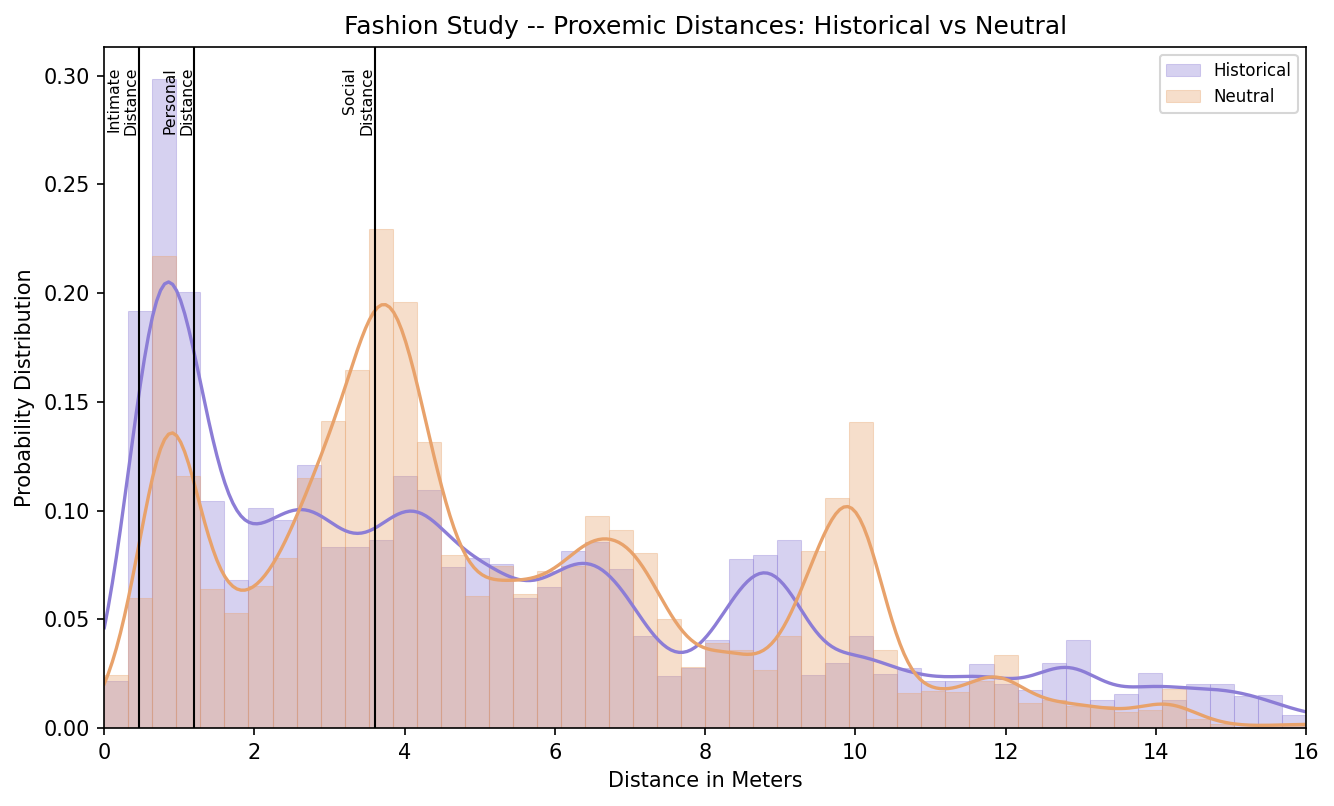

In [1]:
dists_by_cond = {}
for cond in ['H', 'N']:
    sub = specs[specs.condition == cond]
    parts = [pairwise_distances_within_file(long_df[long_df.pair_id == row.pair_id], rate_hz=10.0)
             for _, row in sub.iterrows()]
    dists_by_cond[cond] = np.concatenate(parts) if parts else np.array([])
    d = dists_by_cond[cond]
    print(f"{FASHION_CONDITION_LABEL[cond]:12s}: n={len(d):>8,}  mean={d.mean():.3f} m  median={np.median(d):.3f} m")

fig, ax = plt.subplots(figsize=(9, 5.5))
plot_proxemic_distribution(ax, {FASHION_CONDITION_LABEL[c]: dists_by_cond[c] for c in ['H', 'N']},
                            'Fashion Study -- Proxemic Distances: Historical vs Neutral', xmax=16.0)
plt.tight_layout()
plt.savefig('fashion_proxemics_h_vs_n.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Synchrony -- temporal + social, by condition

In [1]:
rows = []
for pair_id, g in long_df.groupby('pair_id'):
    hz = round(estimate_native_hz(g))
    res = resample_session(g, rate_hz=hz)
    ts = temporal_synchrony(res, fps=hz, window_s=SYNC_WINDOW_S)
    ss = social_synchrony(res, fps=hz, window_s=SYNC_WINDOW_S)
    cond = specs.loc[specs.pair_id == pair_id, 'condition'].iloc[0]
    rows.append({'pair_id': pair_id, 'condition': cond, 'native_hz': hz,
                 'temporal_sync_mean': ts['synchrony'].mean() if len(ts) else np.nan,
                 'social_sync_mean_r': ss['pearson_r'].mean() if len(ss) else np.nan})
sync_per_pair = pd.DataFrame(rows)
sync_summary = sync_per_pair.groupby('condition')[['temporal_sync_mean', 'social_sync_mean_r']].agg(['mean', 'std']).round(3)
sync_summary

          temporal_sync_mean        social_sync_mean_r       
                        mean    std               mean    std
condition                                                    
H                      0.567  0.014              0.138  0.030
N                      0.555  0.018              0.113  0.039

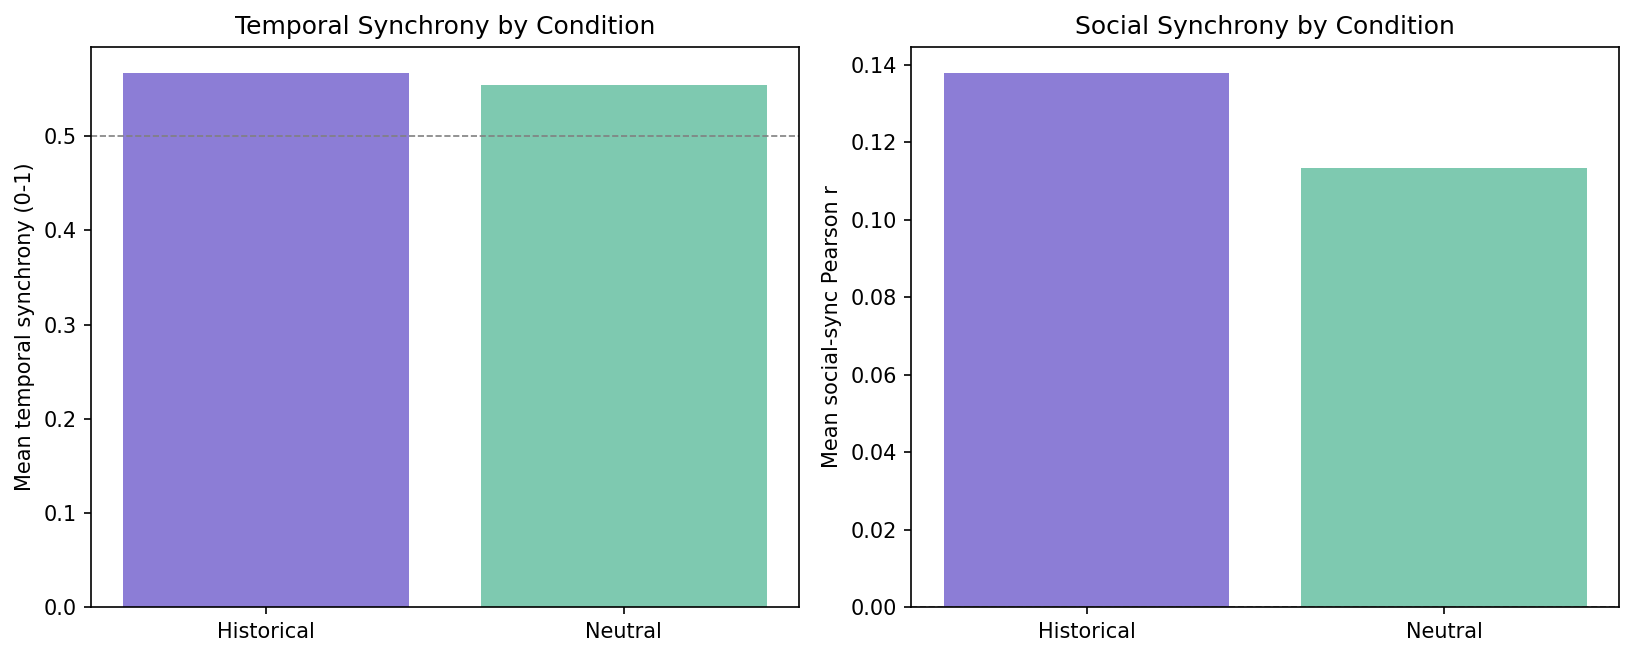

    pair_id condition  native_hz  temporal_sync_mean  social_sync_mean_r
0   H01_H02         H         10            0.579329            0.177594
1   H03_H04         H         10            0.575985            0.159053
2   H05_H06         H         10            0.567615            0.156879
3   H07_H08         H         10            0.550244            0.107568
4   H09_H10         H         10            0.560002            0.113409
5   H11_H12         H         10            0.564503            0.124932
6   H13_H14         H         10            0.573763            0.157089
7   H15_H16         H         10            0.560921            0.125906
8   H17_H18         H         10            0.556269            0.113900
9   H19_H20         H         10            0.545387            0.097524
10  H21_H22         H         10            0.579320            0.154721
11  H23_H24         H         10            0.598793            0.195324
12  H25_H26         H         10            0.56885

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
order = ['H', 'N']
labels = [FASHION_CONDITION_LABEL[c] for c in order]
axes[0].bar(labels, [sync_per_pair[sync_per_pair.condition == c]['temporal_sync_mean'].mean() for c in order],
            color=['#8c7dd6', '#7ec9b0'])
axes[0].axhline(0.5, color='gray', ls='--', lw=0.8)
axes[0].set_ylabel('Mean temporal synchrony (0-1)'); axes[0].set_title('Temporal Synchrony by Condition')
axes[1].bar(labels, [sync_per_pair[sync_per_pair.condition == c]['social_sync_mean_r'].mean() for c in order],
            color=['#8c7dd6', '#7ec9b0'])
axes[1].axhline(0, color='gray', ls='--', lw=0.8)
axes[1].set_ylabel('Mean social-sync Pearson r'); axes[1].set_title('Social Synchrony by Condition')
plt.tight_layout()
plt.savefig('fashion_synchrony_by_condition.png', dpi=150, bbox_inches='tight')
plt.show()

sync_per_pair.sort_values(['condition', 'pair_id']).reset_index(drop=True)

## 4. Locus-of-Focus export

Each fashion session file is already a complete dyad-together segment (no
slicing needed), so this exports one LOF-ready pickle per session directly:
axis swap (`position_y`&harr;`position_z`, `direction_y`&harr;`direction_z`),
required placeholder fields, columns aligned to the `group8_small_yesand.pkl`
reference schema (62 columns).

In [1]:
REF_COLS = list(pd.read_pickle(REF_PKL).columns)
print(f'Reference schema: {len(REF_COLS)} columns')

LOF_DIR = DATA_DIR / 'locus_ready' / 'fashion'
LOF_DIR.mkdir(parents=True, exist_ok=True)

exported = []
for p in sorted((DATA_DIR / 'fashion').glob('*_session.csv')):
    raw = read_raw_hybrid_file(p)
    out_path = LOF_DIR / (p.stem + '.pkl')
    df_lof = export_lof_pickle(raw, REF_COLS, out_path)
    exported.append(str(out_path.relative_to(DATA_DIR)))
    print(f'  saved: {out_path.relative_to(DATA_DIR)}  ({len(df_lof)} rows, '
          f'{df_lof["uuid"].nunique()} participants, {len(df_lof.columns)} cols)')

print(f'\nExported {len(exported)} LOF-ready pickles -> {LOF_DIR}')

Reference schema: 62 columns
  saved: locus_ready/fashion/H01_H02_session.pkl  (21035 rows, 2 participants, 62 cols)
  saved: locus_ready/fashion/H03_H04_session.pkl  (12106 rows, 2 participants, 62 cols)
  saved: locus_ready/fashion/H05_H06_session.pkl  (11493 rows, 2 participants, 62 cols)
  saved: locus_ready/fashion/H07_H08_session.pkl  (19125 rows, 2 participants, 62 cols)
  saved: locus_ready/fashion/H09_H10_session.pkl  (14413 rows, 2 participants, 62 cols)
  saved: locus_ready/fashion/H11_H12_session.pkl  (19452 rows, 2 participants, 62 cols)
  saved: locus_ready/fashion/H13_H14_session.pkl  (16072 rows, 2 participants, 62 cols)
  saved: locus_ready/fashion/H15_H16_session.pkl  (19675 rows, 2 participants, 62 cols)
  saved: locus_ready/fashion/H17_H18_session.pkl  (19081 rows, 2 participants, 62 cols)
  saved: locus_ready/fashion/H19_H20_session.pkl  (28852 rows, 2 participants, 62 cols)
  saved: locus_ready/fashion/H21_H22_session.pkl  (21104 rows, 2 participants, 62 cols)
  s

## 5. Summary

In [1]:
print('=== Proxemics ===')
for cond in ['H', 'N']:
    d = dists_by_cond[cond]
    print(f"  {FASHION_CONDITION_LABEL[cond]:12s}: mean={d.mean():.3f} m  median={np.median(d):.3f} m  (n={len(d):,})")
print()
print('=== Synchrony ===')
print(sync_summary)
print()
print(f'=== Locus of Focus ===')
print(f'{len(exported)} pickles exported to Data/locus_ready/fashion/')

=== Proxemics ===
  Historical  : mean=5.121 m  median=4.164 m  (n=127,282)
  Neutral     : mean=5.278 m  median=4.259 m  (n=111,900)

=== Synchrony ===
          temporal_sync_mean        social_sync_mean_r       
                        mean    std               mean    std
condition                                                    
H                      0.567  0.014              0.138  0.030
N                      0.555  0.018              0.113  0.039

=== Locus of Focus ===
28 pickles exported to Data/locus_ready/fashion/
